# Task 1
1. Установите библиотеку sympy.
2. Используя ее функции, напишите свою функцию, которая на вход примет математическую функцию $ y=f(x)$ вида $x^2 - x + 21$, и вернёт производную: $2𝑥−1$.

In [1]:
import sympy
from sympy import diff, Symbol
from sympy.parsing.sympy_parser import parse_expr

In [2]:
def get_derivative(equation, variable='x'):
    return diff(parse_expr(equation), variable)

In [3]:
get_derivative('x**2 - x + 21')

2*x - 1

In [4]:
get_derivative('x**3 - 2 * x + 42')

3*x**2 - 2

# Task 2
Напишите функцию, которая на вход примет математическую функцию `p = f(x, y)`, 
зависящую от двух переменных вида `(x-y)**2`, а также ту переменную, по которой нужно посчитать частную производную.
Функция должна вернуть частную производную по выбранной переменной.

In [5]:
get_derivative('(x - y)**2')

2*x - 2*y

In [6]:
get_derivative('(x - y)**2', 'y')

-2*x + 2*y

In [7]:
get_derivative('(x - y)**3', 'x')

3*(x - y)**2

In [8]:
get_derivative('(x - y)**3', 'y')

-3*(x - y)**2

# Task 3

Представь, что у нас есть истинное значений `y_true` и предсказанное значение `y_pred`, описанное линейнным уравнением вида `y_pred = w*x + b`
1. Выведите формулу квадратного отклонения между истинным и предсказанным значениями. 
2. Вычислите частные производные полученной формулы по переменным w и b.

In [9]:
import numpy as np

In [10]:
parse_expr('(Y - (x * w + b))**2')

(Y - b - w*x)**2

In [11]:
get_derivative('(Y - (x * w + b))**2', 'w')

-2*x*(Y - b - w*x)

In [12]:
get_derivative('(Y - (x * w + b))**2', 'b')

-2*Y + 2*b + 2*w*x

In [13]:
def weight_derivative(equation):
    return get_derivative(equation, 'w'), get_derivative(equation, 'b')

In [14]:
weight_derivative('(Y - (x * w + b))**2')

(-2*x*(Y - b - w*x), -2*Y + 2*b + 2*w*x)

In [15]:
def mse(X, Y, w, b):
    return np.mean((Y - (X * w + b))**2)

# Task 4
1. В этот раз тебе нужно написать класс `Gradient()`, который будет состоять из нескольких методов. Объект при 
инициализации получает два вектора: `X`, `Y`. Далее методы обращаются к ним уже внутри класса.
    - `predict`: на вход она получает `w`, `b`, на выход она выдаёт прогнозные значения `Y_pred`;
    - `mse`: на вход она получает `Y_pred`, на выход выдает посчитанное MSE;
    - `update`: на вход она получает `w`, `b` и `a` (наш learning rate). Сделайте по умолчанию значение `a=0.0001`. А на 
выходe метод выдаёт новые значения `w`, `b`, которые обновились благодаря посчитанным градиентам.
2. Проверь работу методов, подав на вход класса два вектора `X`, `Y` и начальные параметры `w`, `b` в требуемые методы.

In [16]:
class Gradient:
    
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        
    def predict(self, w, b):  
        return (self.X * w + b)
    
    def mse(self, Y_pred, w, b):
        return mse(self.X, self.Y, w, b)

    def update(self, w, b, a=0.0001):
        new_w = w - a * np.mean((-2 * self.X * (self.Y - self.predict(w, b))))
        new_b = b - a * np.mean((-2 * (self.Y - self.predict(w, b))))
        return new_w, new_b

In [17]:
X = np.array(
    [32.50234527, 53.42680403, 61.53035803, 47.47563963, 59.81320787, 55.14218841, 
     52.21179669, 39.29956669, 48.10504169, 52.55001444, 45.41973014, 54.35163488, 
     44.1640495 , 58.16847072, 56.72720806, 48.95588857, 44.68719623, 60.29732685, 
     45.61864377, 38.81681754]
)
Y = np.array(
    [31.70700585, 68.77759598, 62.5623823 , 71.54663223, 87.23092513, 78.21151827, 
     79.64197305, 59.17148932, 75.3312423 , 71.30087989, 55.16567715, 82.47884676, 
     62.00892325, 75.39287043, 81.43619216, 60.72360244, 82.89250373, 97.37989686, 
     48.84715332, 56.87721319]
)

In [18]:
import matplotlib.pyplot as plt

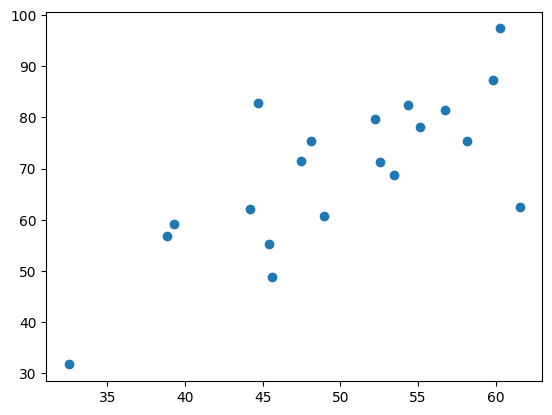

In [19]:
plt.scatter(X, Y);

In [20]:
grad = Gradient(X, Y)

In [21]:
Y_pred = grad.predict(w=0.5,b=4)

In [22]:
mse_now = grad.mse(Y_pred, w=0.5,b=4)

In [23]:
mse_now

1784.8517253411974

## Task 5
Улучшите ваш код таким образом, чтобы появился метод `optimize`. Он должен итеративным образом пройти какое-то количество раз обновление значений `w`, `b`, придя к оптимальному значению. Критерии останова:
 - если было превышено количество заранее заданных итераций `num_iterations`;
 - если новая итерация выдала разницу между текущей ошибкой и ошибкой прошлой итерации значение, меньшее, чем `stopping_threshold`;
 - метод должен вернуть финальные значения `w`, `b`, и `mse`.


In [24]:
import matplotlib.pyplot as plt

In [25]:
class GradientDescent(Gradient):
    
    def __init__(self, X, Y, w=0, b=0):
        super().__init__(X, Y)
        self.w = w
        self.b = b
        
    def optimize(self, num_iterations, stopping_threshold=0.001, learning_rate=0.000001):
        mse_history = [0, ]
        for i in range(num_iterations):
            Y_pred = self.predict(self.w, self.b)
            mse_pred = self.mse(Y_pred, w=self.w, b=self.b)
            prev_mse = mse_history[i - 1]
            mse_history.append(mse_pred)
            if abs(mse_pred - prev_mse) <= stopping_threshold:
                print(f'Step {i}, MSE: {mse_pred}, MSE prev: {prev_mse}, Diff: {abs(mse_pred - prev_mse)}')
                break
            if i % 10 == 0:
                print(f'Step {i}, MSE: {mse_pred}, MSE prev: {prev_mse}, Diff: {abs(mse_pred - prev_mse)}')
            self.w, self.b = self.update(self.w, self.b, a=learning_rate)

        return self.w, self.b, mse_pred, mse_history

In [26]:
X = np.array(
     [32.50234527, 53.42680403, 61.53035803, 47.47563963, 59.81320787, 55.14218841, 
      52.21179669, 39.29956669, 48.10504169, 52.55001444, 45.41973014, 54.35163488, 
      44.1640495 , 58.16847072, 56.72720806, 48.95588857, 44.68719623, 60.29732685, 
      45.61864377, 38.81681754]
); 

Y = np.array([31.70700585, 68.77759598, 62.5623823 , 71.54663223, 87.23092513, 
              78.21151827, 79.64197305, 59.17148932, 75.3312423 , 71.30087989, 
              55.16567715, 82.47884676, 62.00892325, 75.39287043, 81.43619216, 
              60.72360244, 82.89250373, 97.37989686, 48.84715332, 56.87721319]
)

In [27]:
gd = GradientDescent(X, Y, )

In [28]:
w, b, mse_now, mse_history = gd.optimize(num_iterations=1000, learning_rate=0.0001, stopping_threshold=0.001)

Step 0, MSE: 5038.357337690139, MSE prev: 0, Diff: 5038.357337690139
Step 10, MSE: 98.64071863543336, MSE prev: 98.69016673056166, Diff: 0.049448095128298064
Step 13, MSE: 98.63776448780798, MSE prev: 98.6384399082435, Diff: 0.0006754204355132742


In [29]:
mse_now

98.63776448780798

In [30]:
len(mse_history)

15

In [31]:
w, b

(1.3897758147166062, 0.027080899850779064)

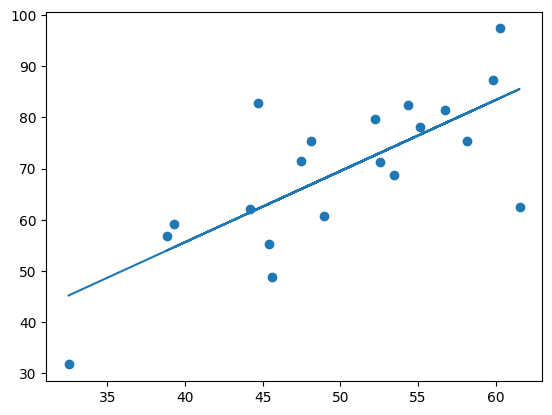

In [32]:
plt.scatter(X, Y);
plt.plot(X, w*X + b);

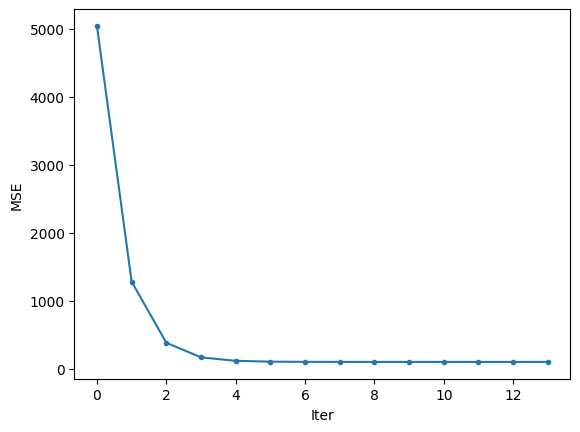

In [33]:
plt.plot(list(range(len(mse_history[1:]))), mse_history[1:], marker='.')
plt.xlabel('Iter')
plt.ylabel('MSE');